In [55]:
# general packages
import numpy as np
import pandas as pd

# packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# packages for scRNA and ST
import scanpy as sc
import squidpy as sq

# 1. Introduction

In this notebook we analyse spatial transcriptomics data with [scanpy](https://scanpy.readthedocs.io/en/stable/) and [squidpy](https://squidpy.readthedocs.io/en/stable/). The example merfish dataset (slices from mouse hypothalamic preoptic region) is from [this article](https://www.science.org/doi/10.1126/science.aau5324) and available [through Python](https://squidpy.readthedocs.io/en/stable/api/squidpy.datasets.merfish.html#squidpy.datasets.mer). We largely follow the steps from these [merfish](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_merfish.html) and [vizgen](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_vizgen.html) tutorials.

# 2. Read in data

The data are available as AnnData object within squidpy. See more about it [here](https://anndata.readthedocs.io/en/latest/tutorials/notebooks/getting-started.html). We explore the content of this data object in the following code chunks. The most important columns are the cell type labels and Bregma (to identify slices). Note: while these data are suitable for three-dimensional visualisations and analysis, the main analysis will be done on a single slice only.

In [2]:
# import and inspect built-in merfish data

adata = sq.datasets.merfish()

In [3]:
# get an overview of the object
adata

AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'

In [4]:
# inspecting count matrix
# sparse matrix
adata.X

<73655x161 sparse matrix of type '<class 'numpy.float32'>'
	with 4660375 stored elements in Compressed Sparse Row format>

In [5]:
# number of observations/cells
adata.n_obs

73655

In [6]:
# number of variables/genes
adata.n_vars

161

In [7]:
# shape
adata.shape

(73655, 161)

In [8]:
# the name of cells
adata.obs_names

Index(['67146-0', '67147-0', '67148-0', '67149-0', '67150-0', '67151-0',
       '67152-0', '67153-0', '67154-0', '67155-0',
       ...
       '5574-11', '5575-11', '5576-11', '5577-11', '5578-11', '5579-11',
       '5580-11', '5581-11', '5582-11', '5583-11'],
      dtype='object', length=73655)

In [9]:
# the name of genes
adata.var_names

Index(['Ace2', 'Adora2a', 'Aldh1l1', 'Amigo2', 'Ano3', 'Aqp4', 'Ar',
       'Arhgap36', 'Avpr1a', 'Avpr2',
       ...
       'Penk', 'Scg2', 'Sln', 'Sst', 'Tac1', 'Tac2', 'Th', 'Trh', 'Ucn3',
       'Vgf'],
      dtype='object', length=161)

In [10]:
# additional inoformation of cells
# most important columns: Cell_class (which is the cell type label), Bregma (which identifies slices), batch and the spatial coordinates
adata.obs

,Cell_ID,Animal_ID,Animal_sex,Behavior,Bregma,Centroid_X,Centroid_Y,Cell_class,Neuron_cluster_ID,batch
67146-0,6d6b1d59-6f3b-4a9d-b5a4-8c8b073ae025,1,Female,Naive,-29.0,467.385973,-3983.113569,OD Mature 2,nan,0
67147-0,76200644-c14a-4cfa-8752-2a02e5f10d20,1,Female,Naive,-29.0,509.950521,-3950.118553,OD Immature 1,nan,0
67148-0,6b08ca36-b395-415a-bb34-d7b67550c35d,1,Female,Naive,-29.0,523.114231,-3992.774432,Inhibitory,I-7,0
67149-0,b9cb9cfb-fff7-426e-8c36-18fe428ca156,1,Female,Naive,-29.0,519.804086,-3943.176495,Excitatory,E-13,0
67150-0,982cc0fc-6d11-4dc4-9ffc-c8c0cee48e6d,1,Female,Naive,-29.0,536.690339,-3948.855437,OD Mature 2,nan,0
...,...,...,...,...,...,...,...,...,...,...
5579-11,681fa623-a123-414a-88cf-938ee031772c,1,Female,Naive,26.0,-1430.494998,3594.782213,Astrocyte,nan,11
5580-11,9f98c288-8825-42b1-a369-4a4aab973188,1,Female,Naive,26.0,-1574.375277,4183.177498,Inhibitory,I-6,11
5581-11,17ef8dff-989e-4565-b657-9f7195b049d9,1,Female,Naive,26.0,-1531.108030,4181.272965,Endothelial 1,nan,11
5582-11,aef1c6c6-55ed-4a75-afcb-99a006dda081,1,Female,Naive,26.0,-1475.241835,4185.236063,Inhibitory,I-1,11


In [11]:
# Identifying slices
adata.obs['Bregma'].unique()

array([-29., -24., -19., -14.,  -9.,  -4.,   1.,   6.,  11.,  16.,  21.,
        26.])

In [12]:
# frequency of cell_types

adata.obs['Cell_class'].value_counts()

Cell_class
Inhibitory       24761
Excitatory       11757
Ambiguous         9282
Astrocyte         8393
OD Mature 2       5736
Endothelial 1     3799
OD Immature 1     2457
Ependymal         1961
Microglia         1472
Endothelial 3     1369
OD Mature 1        952
Pericytes          638
Endothelial 2      581
OD Mature 4        367
OD Immature 2       91
OD Mature 3         39
Name: count, dtype: int64

# 2. Visualization

We can visualize the cell types, for instance, either as 3D or 2D (slice) data. Fot this, we need to know which variable identifies the slides. Here it is Bregma.

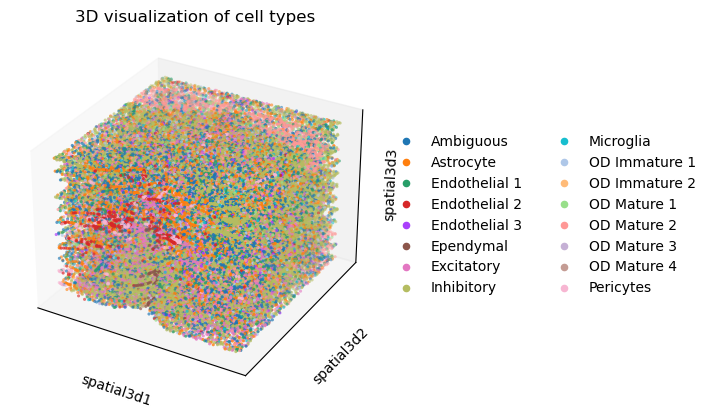

In [13]:
# 3d visualization
# we can color by any variable in the obs instance
# cell types are known labels

sc.pl.embedding(adata, basis="spatial3d", projection="3d", color="Cell_class", title="3D visualization of cell types")

In [14]:
# 2d visualization of the slice Bregma==-4

## saving this single slice as adata object
adata_slice_min4 = adata[adata.obs.Bregma == -4].copy()

# inspect new object
adata_slice_min4


AnnData object with n_obs × n_vars = 6154 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'

C:\Users\Kati\anaconda3\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


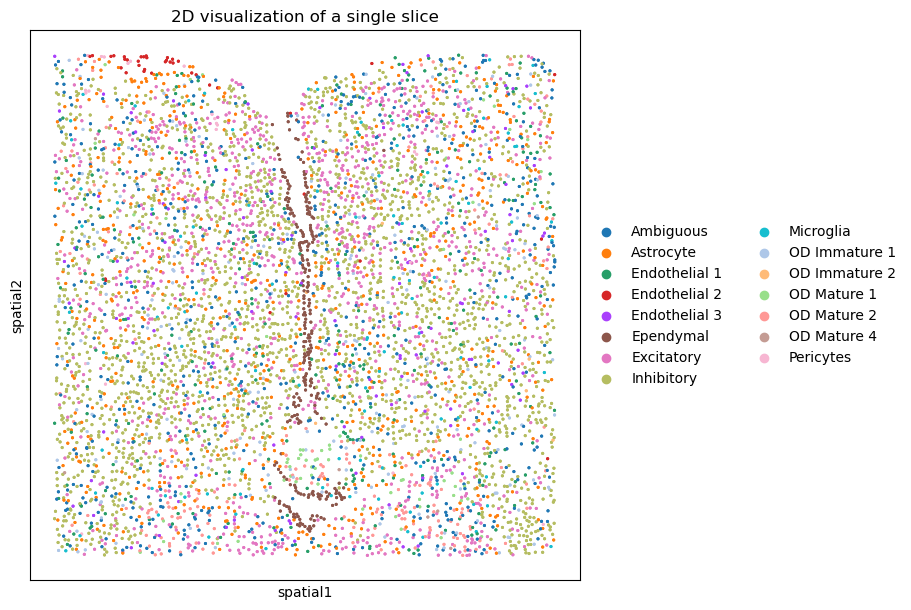

In [15]:
# visualizing slice
sq.pl.spatial_scatter(adata_slice_min4, shape=None, color="Cell_class", size=6, title="2D visualization of a single slice", figsize=[9,9])

# 3. The spatial analysis of cell types

The aim of this subsection is to find out if there is non-randomness in the location of cell types within the tissue. Looking at the 2D scatter plot above, we suspect that this is the case. While there are various options to further investigate this, we make use of the following only: neighborhood enrichment score, co-occurrence, various centrality scores and Ripley's measures.

## 3.1. Neighborhood enrichment

Useful material:

https://www.sc-best-practices.org/spatial/neighborhood.html

https://www.nature.com/articles/s41592-021-01358-2#Sec7

First, we calculate and visualize neighborhood enrichment of cell types in the 2D slice prepared above. Running the code below adds new items to the anndata object (we have now obsp and spatial neighbors and cell_class_nhood_enrichment within uns).

In [19]:
# creating neighborhood graph
sq.gr.spatial_neighbors(adata_slice_min4, coord_type="generic")
# calculating neighborhood enrichment
sq.gr.nhood_enrichment(adata_slice_min4, cluster_key="Cell_class")


  0%|          | 0/1000 [00:00<?, ?/s]

In [18]:
# observe new items added to the aandata object
# these new items are based on the neighborhood calculations above
adata_slice_min4

AnnData object with n_obs × n_vars = 6154 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors', 'spatial_neighbors', 'Cell_class_nhood_enrichment'
    obsm: 'spatial', 'spatial3d'
    obsp: 'spatial_connectivities', 'spatial_distances'

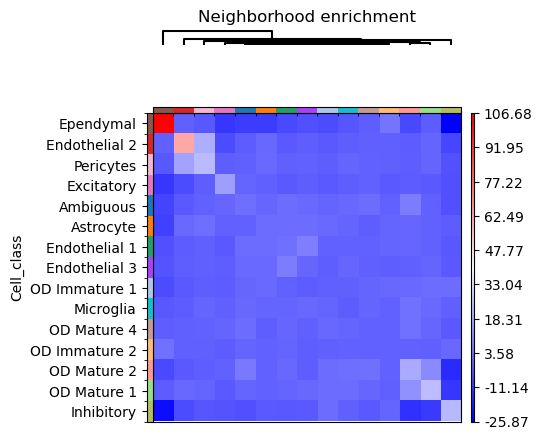

In [20]:
# plotting neighborhood enrichment
sq.pl.nhood_enrichment(
    adata_slice_min4, cluster_key="Cell_class", method="single", cmap="bwr", figsize=[4,4], title="Neighborhood enrichment")

Conclusion: Interestingly, we do not find high scores (shades of red) in the diagonal. This means that not many cell types are co-localized with itself. In fact, it seems that we have only two such cell types, namely ependymal and endothelial 2. Indeed, looking at the scatter plot above, we find that the brown dots referring to ependymal cells (center) and the red dots referring to endothelial 2 cells (top left area) are indeed found around each other. Microglia cells, light blue in the scatter plot, on the other hand are very much scattered in the tissue slice, hence the low enrichment value in the diagonal. Inhibitory and OD Mature 2 have negative enrichment score, so they tend to "avoid" each other. Since it is not easy to inspect these patterns in the scatter plot where each cell type is visualized at the same time, we redo the scatter plots highlighting only the cell types or cell clusters of interest named above.

C:\Users\Kati\anaconda3\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
C:\Users\Kati\anaconda3\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
C:\Users\Kati\anaconda3\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


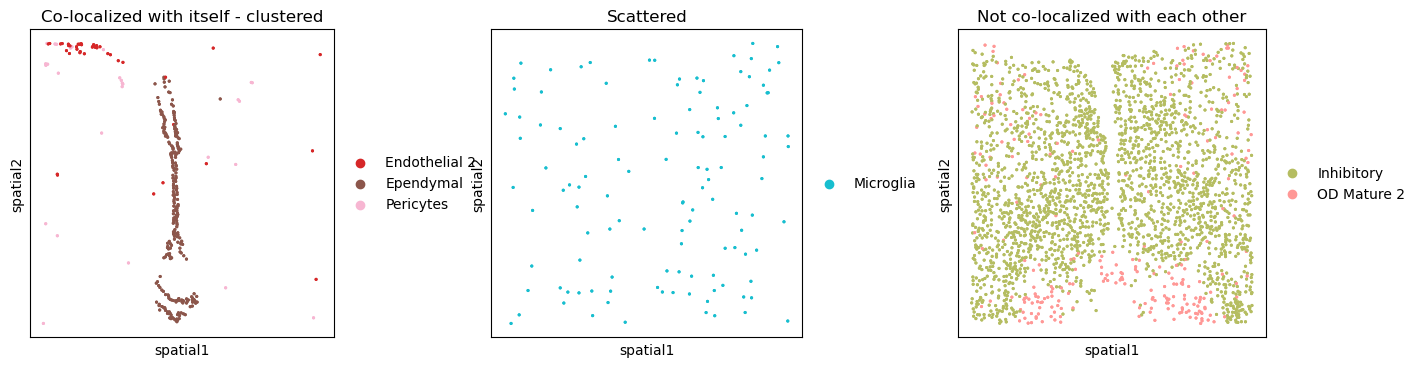

In [56]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(17,4))
sq.pl.spatial_scatter(adata_slice_min4, shape=None, color="Cell_class", size=6, title="Co-localized with itself - clustered",
                     groups=["Ependymal", "Endothelial 2", "Pericytes" ], ax=ax1)
sq.pl.spatial_scatter(adata_slice_min4, shape=None, color="Cell_class", size=6, title="Scattered",
                     groups=["Microglia"], ax=ax2)
sq.pl.spatial_scatter(adata_slice_min4, shape=None, color="Cell_class", size=6, title="Not co-localized with each other",
                     groups=["OD Mature 2", "Inhibitory"], ax=ax3)
plt.show()

## 3.2. Co-occurrence

Interesting material and the explanation of the measure is presented [here](https://www.sc-best-practices.org/spatial/neighborhood.html#co-occurrence-across-spatial-dimensions). We explain the patterns related to the ependymal cell type. These cells are located alongside a vertical line in the centre of the tissue. The co-occurrance pattern of three cell types stand out: ependymal (brown), OD immature 2 and OD mature 1. These are the cell types which cluster around the ependymal cells. Indeed, if we zoom in on these three cell types in the supporting figure, we find that a large proportion of OD mature 1 cells (green) are very close or relatively close to the ependymal cells (towards the bottom). While there are not many OD Immature 2 (orange) cells, these are also relatively close to the ependymal cells.

In [26]:
sq.gr.co_occurrence(
    adata_slice_min4,
    cluster_key="Cell_class",
)

  0%|          | 0/1 [00:00<?, ?/s]

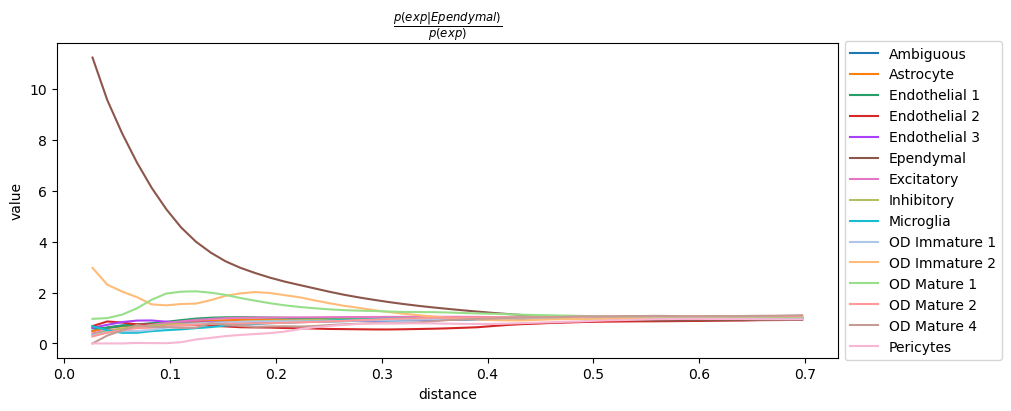

In [43]:
sq.pl.co_occurrence(
    adata_slice_min4,
    cluster_key="Cell_class",
    clusters=["Ependymal"],
    figsize=(10, 4))

C:\Users\Kati\anaconda3\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


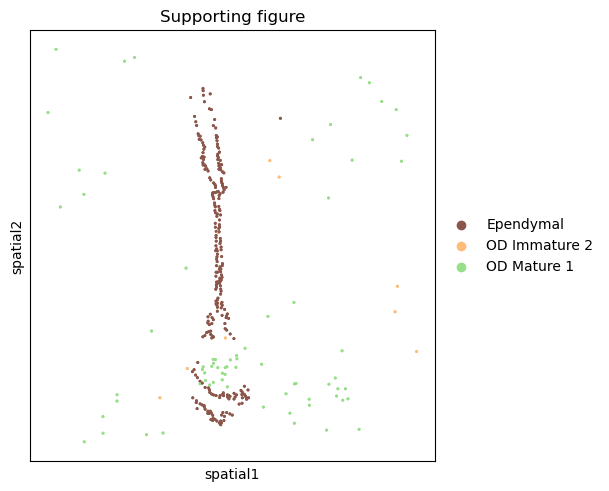

In [45]:
sq.pl.spatial_scatter(adata_slice_min4, shape=None, color="Cell_class", size=5, title="Supporting figure",
                     groups=["OD Mature 1", "OD Immature 2", "Ependymal" ])

plt.show()

## 3.3. Centrality scores

Explanation is found [here](https://squidpy.readthedocs.io/en/latest/notebooks/examples/graph/compute_centrality_scores.html). 
- closeness centrality - measure of how close the group is to other nodes.
- clustering coefficient - measure of the degree to which nodes cluster together.
- degree centrality - fraction of non-group members connected to group member

ThThe measures are presenten both as a table and a graph (same information

Endothelial 2 cells have the highest clustering measure which is logical because almost all cells of this type are located in the upper left corner of the tissue image. The set of cell types with the top 5 closeness and degree centrality is identical: inhibitory, excitatory, astrocyte, ambiguous and endothelial 5.).

In [21]:
sq.gr.centrality_scores(adata_slice_min4, cluster_key="Cell_class")
adata_slice_min4

AnnData object with n_obs × n_vars = 6154 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors', 'spatial_neighbors', 'Cell_class_nhood_enrichment', 'Cell_class_co_occurrence', 'Cell_class_centrality_scores'
    obsm: 'spatial', 'spatial3d'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [22]:
adata_slice_min4.uns['Cell_class_centrality_scores']

,degree_centrality,average_clustering,closeness_centrality
Ambiguous,0.507653,0.505393,0.598473
Astrocyte,0.524455,0.492537,0.594403
Endothelial 1,0.283390,0.510631,0.433460
Endothelial 2,0.018482,0.650765,0.080681
Endothelial 3,0.121212,0.499234,0.267603
Ependymal,0.035109,0.538486,0.070799
Excitatory,0.607600,0.491905,0.620450
Inhibitory,0.765694,0.486592,0.666724
Microglia,0.127589,0.496672,0.281957
OD Immature 1,0.222690,0.499821,0.369388


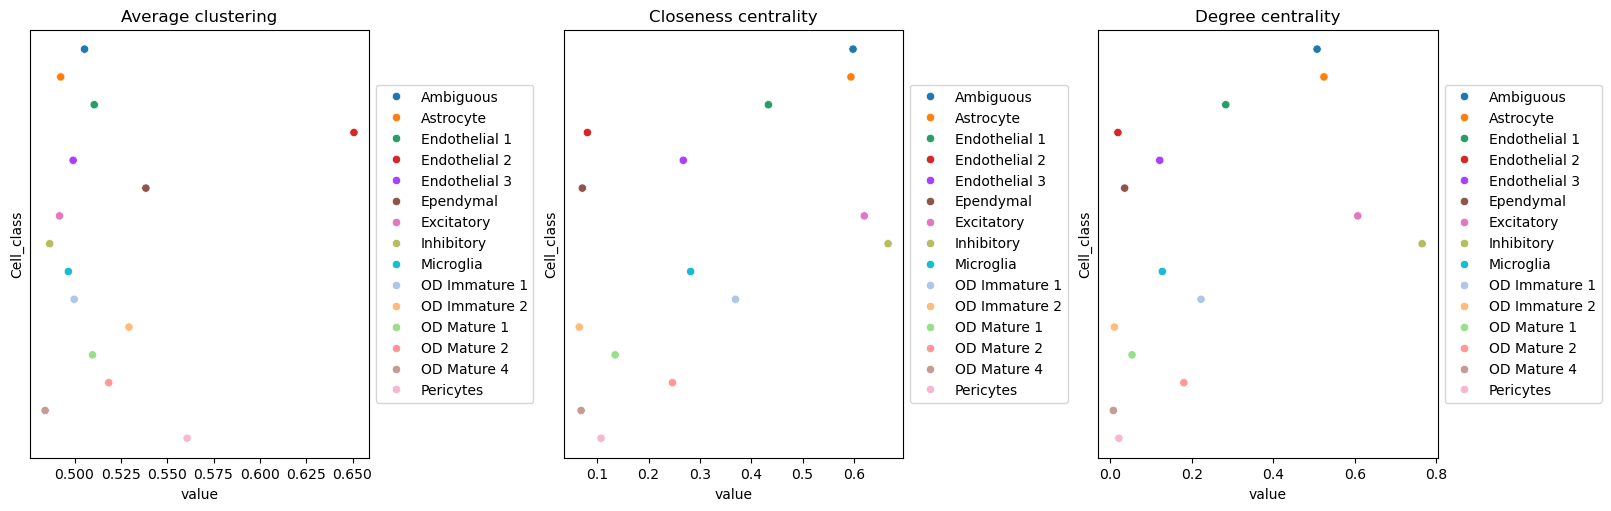

In [23]:
sq.pl.centrality_scores(adata_slice_min4, cluster_key="Cell_class", figsize=(16, 5))

## 3.4. Ripley's scores

These scores tell us if the pattern of points is random, clustered or scattered at different scales. Useful material: https://www3.nd.edu/~mhaenggi/ee87021/Dixon-K-Function.pdf



In [47]:
sq.gr.ripley(adata_slice_min4, cluster_key="Cell_class", mode='L')
adata_slice_min4

AnnData object with n_obs × n_vars = 6154 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors', 'spatial_neighbors', 'Cell_class_nhood_enrichment', 'Cell_class_co_occurrence', 'Cell_class_ripley_L'
    obsm: 'spatial', 'spatial3d'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [50]:
#adata_slice_min4.uns["Cell_class_ripley_L"]

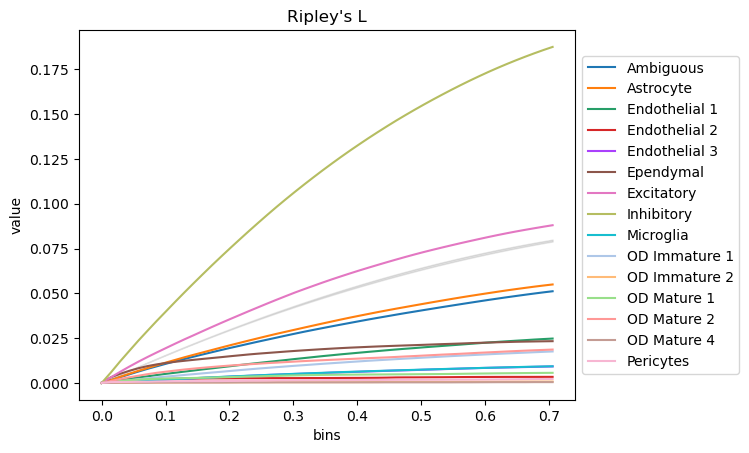

In [28]:
sq.pl.ripley(adata_slice_min4, cluster_key="Cell_class", mode='L')

# 4. The analysis of gene expressions

This section focuses on gene expression.

## 4.1. Highly variable genes

This section investigates which genes are highly variable across cells. Highly variable genes are potential marker genes. Also, we often discard non highly variable genes for downstream analysis. This is a simple single-cell approach and does not take spatial aspects into account. You can find more about the measuring possibilities [here](https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.highly_variable_genes.html). The table below displays the top 50 highly variable genes.

In [51]:
# I run it only our only slice
adata_slice_min4.layers["counts"] = adata_slice_min4.X.copy()
sc.pp.highly_variable_genes(adata_slice_min4, flavor="cell_ranger", n_top_genes=50)
adata_slice_min4

AnnData object with n_obs × n_vars = 6154 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Cell_class_colors', 'spatial_neighbors', 'Cell_class_nhood_enrichment', 'Cell_class_co_occurrence', 'Cell_class_ripley_L', 'hvg'
    obsm: 'spatial', 'spatial3d'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [52]:
# which ones are the highly variable genes
highly_var_genes=adata_slice_min4.var


In [53]:
# the top 50 highly variable genes as dataframe ordered by nomrlaized dispersion
highly_var_genes[(highly_var_genes['highly_variable']==True)].sort_values('dispersions_norm', ascending=False)

,highly_variable,means,dispersions,dispersions_norm
Chat,True,0.309903,32.065004,34.778389
Syt2,True,0.837639,18.446950,27.164875
Npas1,True,0.811905,17.240098,24.921642
Oxt,True,0.064753,8.560525,10.895544
Myh11,True,0.591804,48.080415,9.727189
Slco1a4,True,3.421820,49.927265,8.410621
Klf4,True,0.675590,9.933129,8.355583
Rgs5,True,3.226682,47.427252,6.992444
Pdgfra,True,2.369234,44.560418,5.933990
Rxfp1,True,0.296160,7.871225,5.880378


## 4.2. Differential expression testing and marker genes

Here we perform differential gene expression per cell type. The tests are performed as gene expression in a certain cell type vs. gene expression in the other cell types combined. We show only the top 10 differentially expressed genes.

Interesting questions: 

1. how do variable genes relate to marker genes?
2. how do variable genes relate to spatially variable genes?

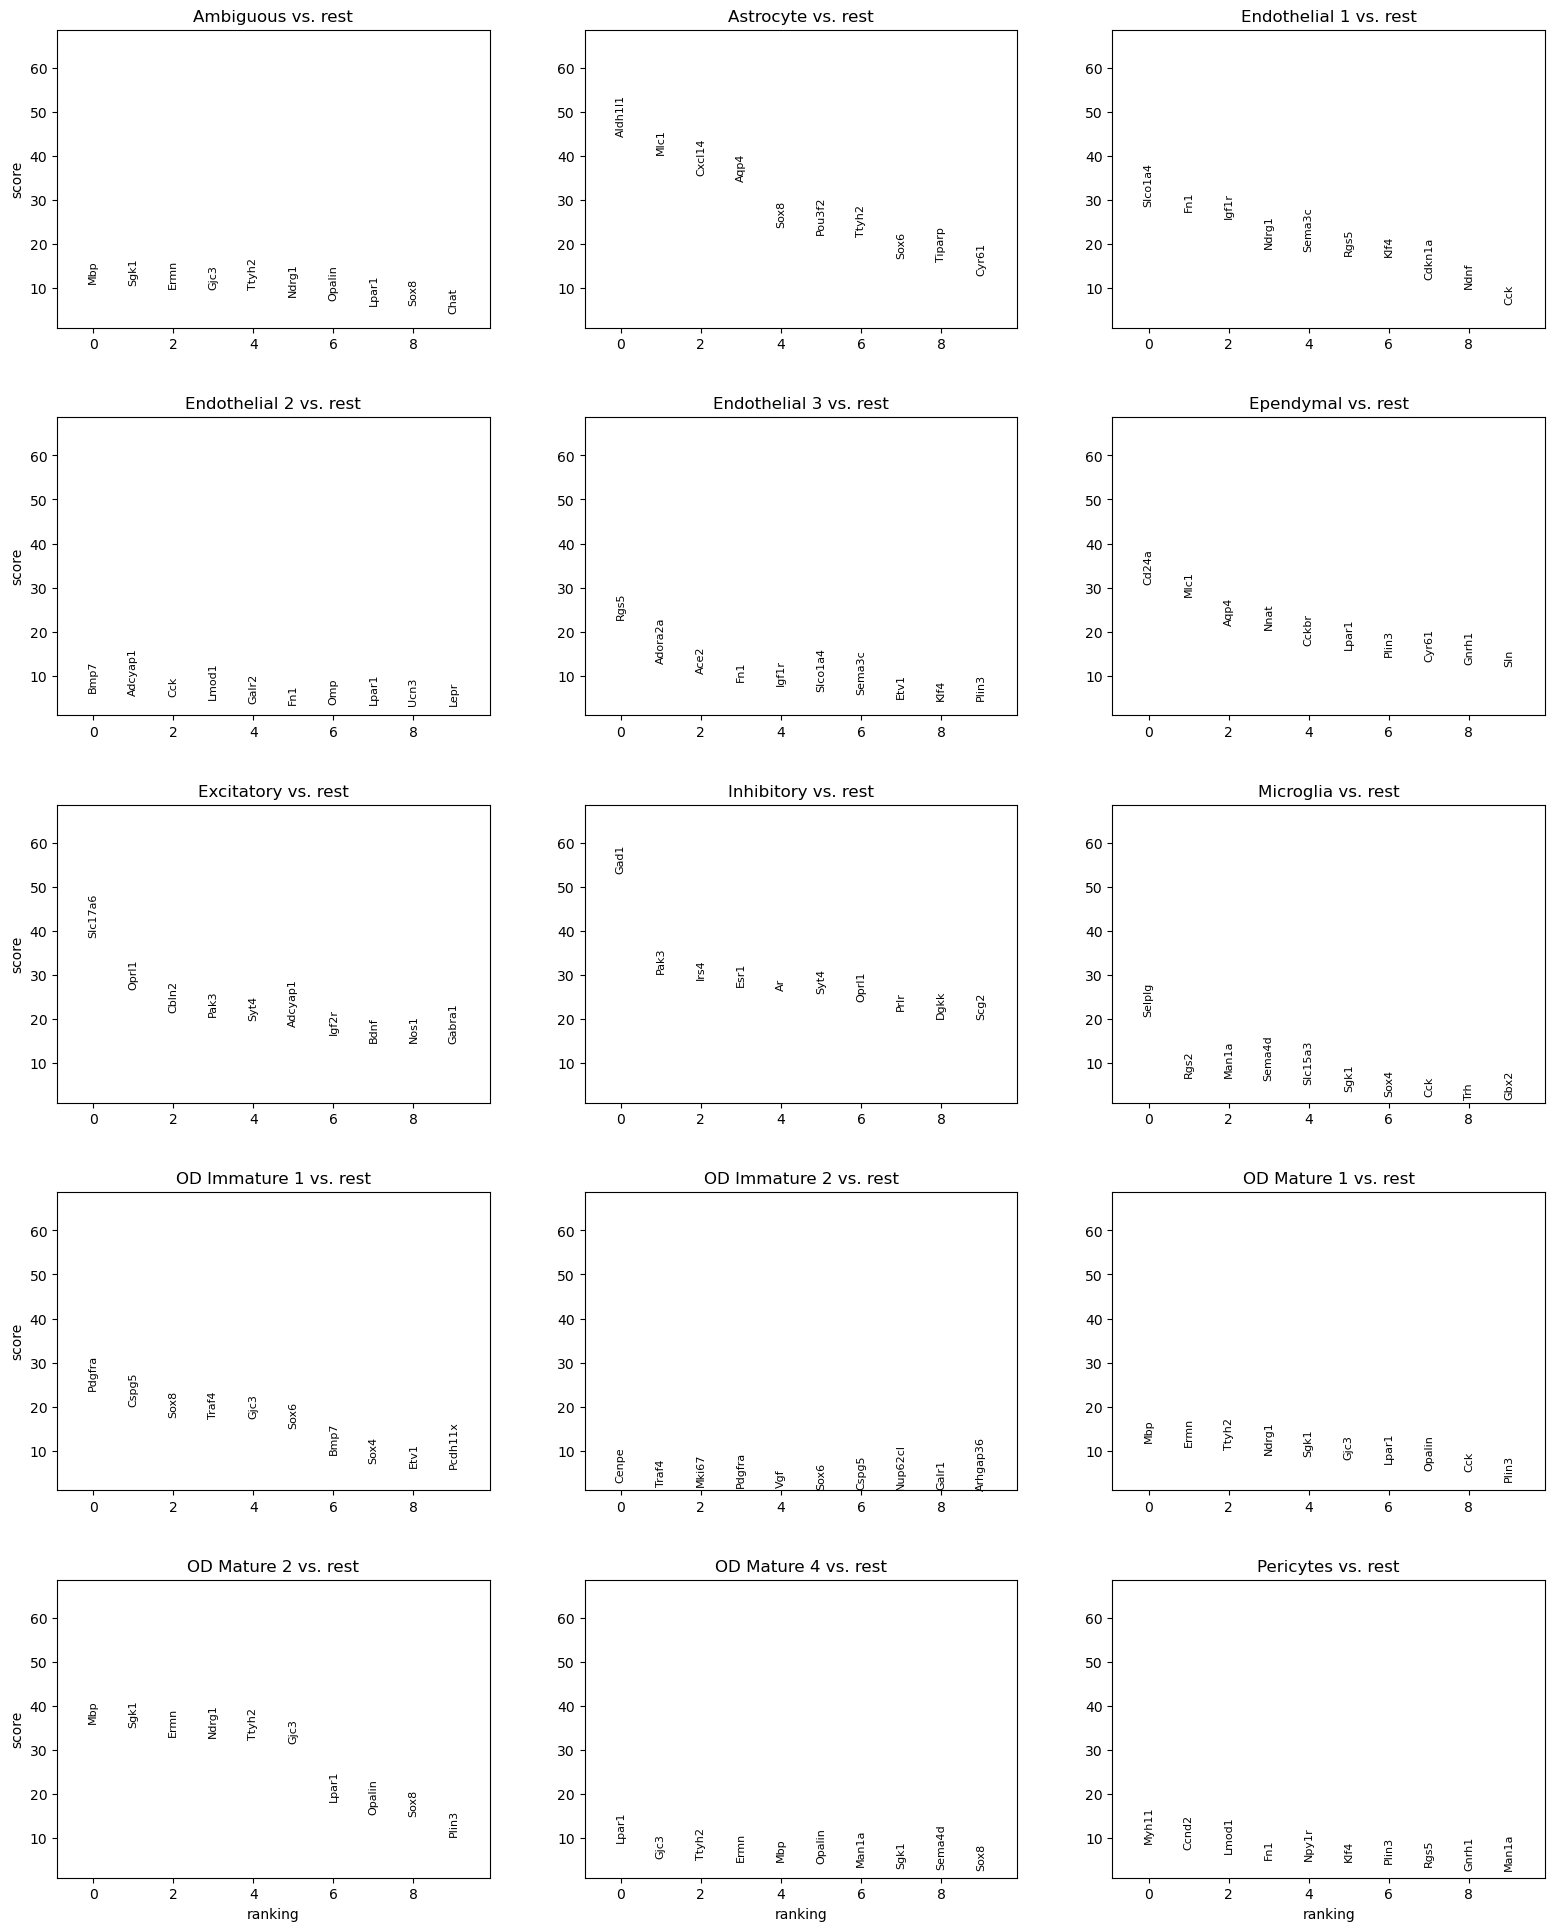

In [32]:
sc.tl.rank_genes_groups(adata_slice_min4, groupby="Cell_class")
sc.pl.rank_genes_groups(adata_slice_min4, groupby="Cell_class", n_genes=10, ncols=3)

In [54]:
# additional info is added to the anndata object
adata_slice_min4

AnnData object with n_obs × n_vars = 6154 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Cell_class_colors', 'spatial_neighbors', 'Cell_class_nhood_enrichment', 'Cell_class_co_occurrence', 'Cell_class_ripley_L', 'hvg'
    obsm: 'spatial', 'spatial3d'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

## 4.3. Spatial autocorrelation of gene expression (spatially variable genes)
The table below shows genes ordered by Moran's I, a spatial autocorrelation measure. The scatter plots display the patterns of the top two (Cd24a and Ebf3, high spatial autocorrelation) and bottom two (Selpig and ttn,low spatial autocorrelation) genes on the tissue. Darker shades mean higher gene expression. In case of genes with high spatial autocorrelation of gene expression, the darker points are located near each other, in a clustered manner. In case of genes with low spatial autocorrelation of gene expression, the dark dots are scattered. Some genes with higher autocorrelation are also in the top highly variably expressed genes and also seem to be marker genes (e.g. Cd24a, Fn1).

In [34]:
sq.gr.spatial_autocorr(adata_slice_min4, mode="moran")
adata_slice_min4.uns["moranI"]

,I,pval_norm,var_norm,pval_norm_fdr_bh
Cd24a,0.509378,0.000000e+00,0.00005,0.000000e+00
Ebf3,0.383260,0.000000e+00,0.00005,0.000000e+00
Slc17a6,0.291465,0.000000e+00,0.00005,0.000000e+00
Ermn,0.248804,0.000000e+00,0.00005,0.000000e+00
Lpar1,0.238096,0.000000e+00,0.00005,0.000000e+00
Lmod1,0.225603,0.000000e+00,0.00005,0.000000e+00
Myh11,0.219548,0.000000e+00,0.00005,0.000000e+00
Th,0.219080,0.000000e+00,0.00005,0.000000e+00
Slc18a2,0.202995,0.000000e+00,0.00005,0.000000e+00
Cyr61,0.196085,0.000000e+00,0.00005,0.000000e+00


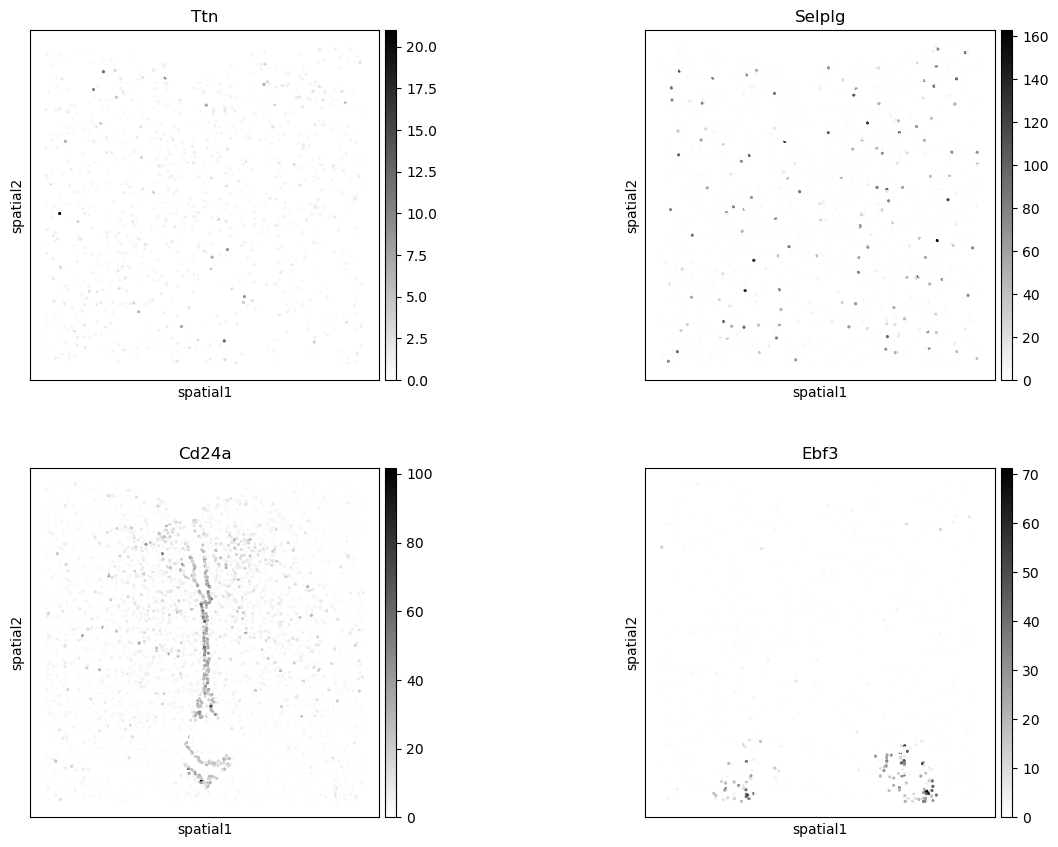

In [35]:
sq.pl.spatial_scatter(
    adata_slice_min4, shape=None, color=["Ttn", "Selplg", "Cd24a", "Ebf3"], size=5, cmap="binary", ncols=2
)

# 5. Cluster analysis

Spatial transcriptomic data contain regular gene expression data and spatial information. The structure of this subsection is as follows:

- Data preprocessing for cluster analysis
- Performing cluster analysis based on gene expression data
- Visualizing clusters and cell types in the two-dimensional space of UMAP axes - do known cell types correspond with the clusters based on gene expression?
- Visualizing and comparing clusters and cell types on the tissue
- Visualizing gene expression of ceetain genes (potential marker genes?) in the two-dimensional space resulting from the cluster analysis
- We perform differential gene expression analysis on the clusters - do the clusters correspond with cell types? We compare marker genes across clusters and cell types.

Main conclusions: 

- The identified clusters based on gene expression correspond reasonably well with cell types (see the figure below with axes UMAP1 and UMAP 2, titled 'leiden' and 'cell_class'). While there are 15 cell types, the number of clusters identified by the algorithm is higher, 17. The two largest cell type groups, namely inhibitory and excitatory, for example, are divided into more than one clusters and the red cluster on the bottom right in the 'leiden' panel covers various cell types, OD mature 1, ambiguous and pericytes.
- Based on the figures below, it is possible to relate the identified clusters to cell types. Example: Cluster 13 in the 'leiden' panel is probably the group of the microglia cell type (see panel cell_class). The set of the most differentially expressed genes, including the top 1, namely Selpig, is the same in cluster 13 (bottom of this notebook) as in the microglia cell type above.
- It would be interesting to further analyse clusters which we cannot directly link to the cell types. Or further analyse the ambiguous cell type. Or cluster 3 which seems to combine various cell types.

In [36]:
sc.pp.normalize_total(adata_slice_min4, inplace=True)
sc.pp.log1p(adata_slice_min4)
sc.pp.pca(adata_slice_min4)
sc.pp.neighbors(adata_slice_min4)
adata_slice_min4

AnnData object with n_obs × n_vars = 6154 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Cell_class_colors', 'spatial_neighbors', 'Cell_class_nhood_enrichment', 'Cell_class_co_occurrence', 'Cell_class_centrality_scores', 'Cell_class_ripley_G', 'Cell_class_ripley_L', 'hvg', 'rank_genes_groups', 'moranI', 'log1p', 'pca', 'neighbors'
    obsm: 'spatial', 'spatial3d', 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances', 'distances', 'connectivities'

In [37]:
adata_slice_min4.uns["neighbors"]

{'connectivities_key': 'connectivities',
 'distances_key': 'distances',
 'params': {'n_neighbors': 15,
  'method': 'umap',
  'random_state': 0,
  'metric': 'euclidean'}}

In [38]:
sc.tl.umap(adata_slice_min4)
sc.tl.leiden(adata_slice_min4)
adata_slice_min4

C:\Users\Kati\AppData\Local\Temp\ipykernel_29600\689316574.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_slice_min4)


AnnData object with n_obs × n_vars = 6154 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Cell_class_colors', 'spatial_neighbors', 'Cell_class_nhood_enrichment', 'Cell_class_co_occurrence', 'Cell_class_centrality_scores', 'Cell_class_ripley_G', 'Cell_class_ripley_L', 'hvg', 'rank_genes_groups', 'moranI', 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'spatial', 'spatial3d', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances', 'distances', 'connectivities'

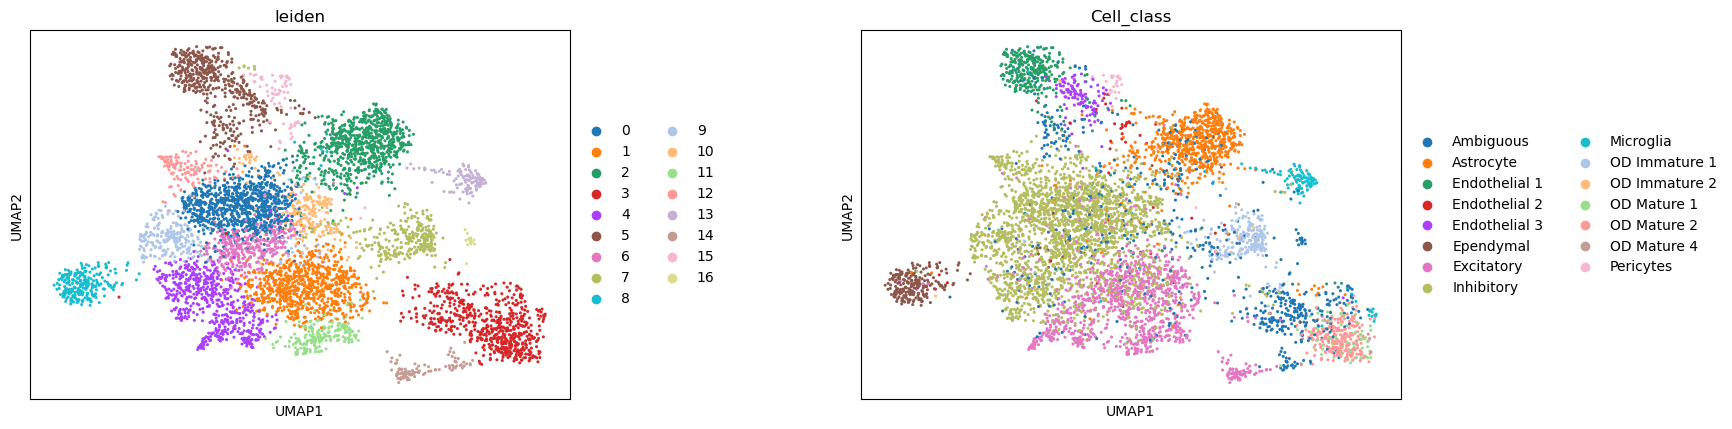

In [39]:
sc.pl.umap(
    adata_slice_min4,
    color=[
        "leiden", "Cell_class"
    ],
    wspace=0.4, 
)

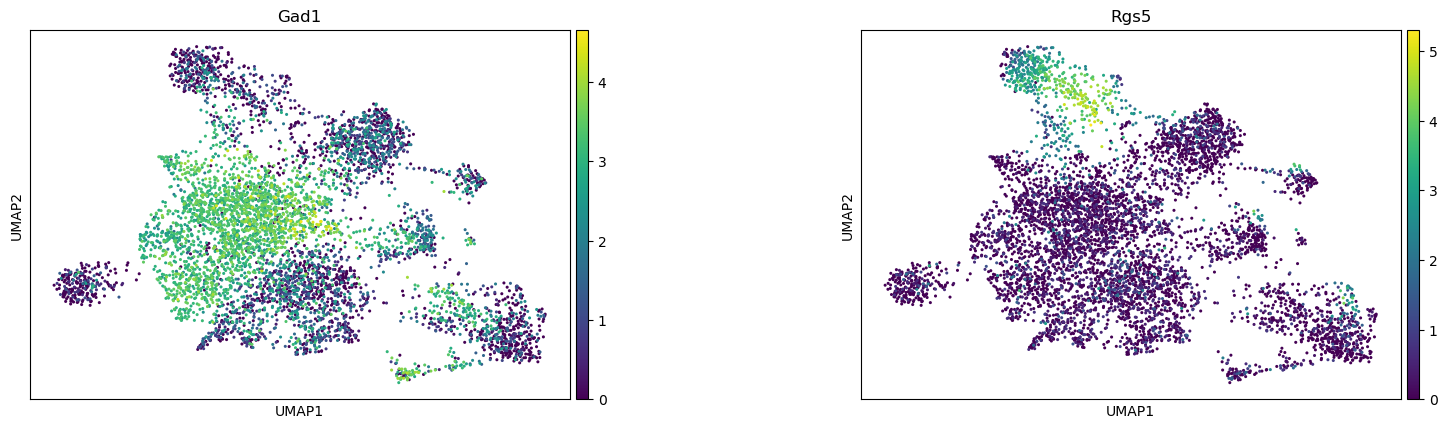

In [44]:
sc.pl.umap(
    adata_slice_min4,
    color=[
        "Gad1", "Rgs5"
    ],
    wspace=0.4, 
)

C:\Users\Kati\anaconda3\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
C:\Users\Kati\anaconda3\Lib\site-packages\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


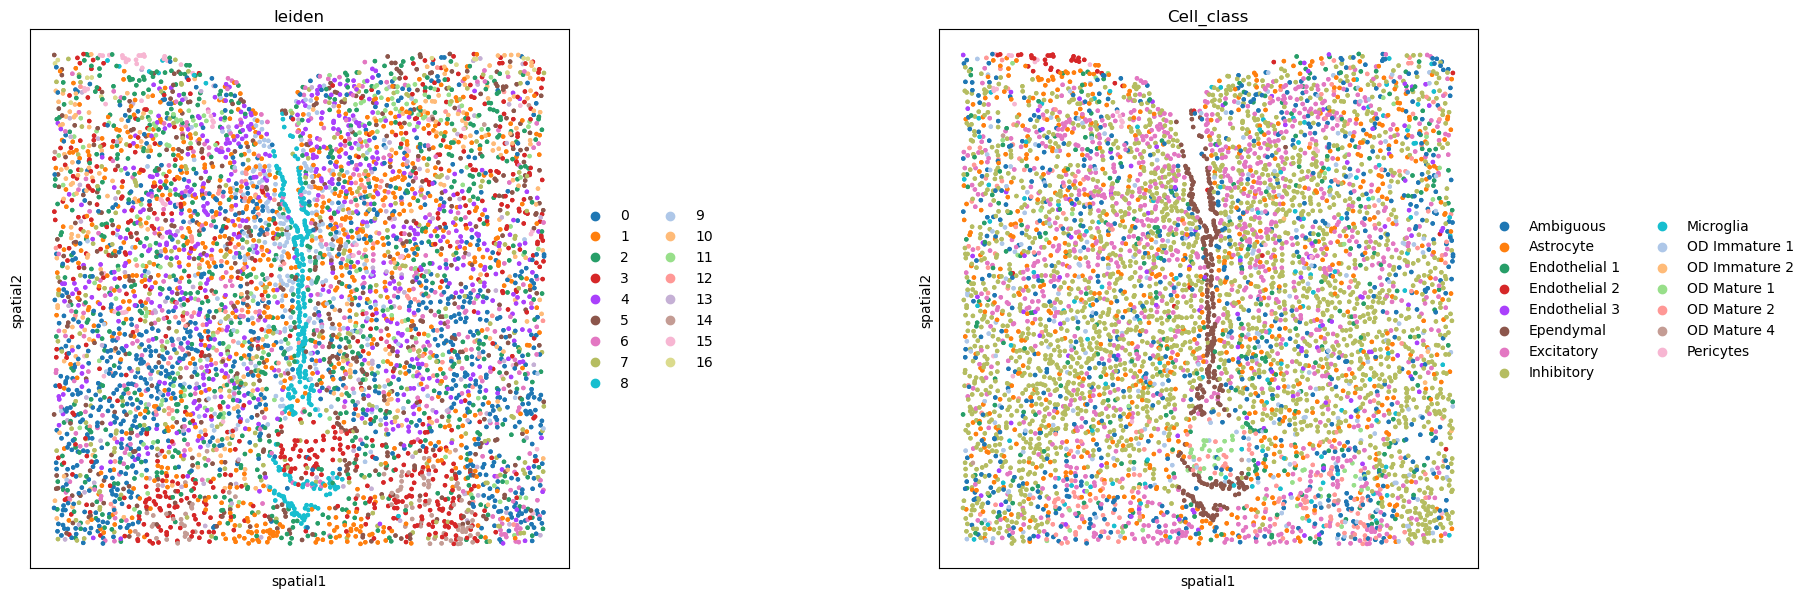

In [41]:
sq.pl.spatial_scatter(
    adata_slice_min4,
    shape=None,
    color=[
        "leiden", "Cell_class"
    ],
    wspace=0.4, figsize=(7, 7)
)

In [42]:
# marker genes by cluster instead of cell_type

sc.tl.rank_genes_groups(adata_slice_min4, groupby="leiden")
adata_slice_min4

AnnData object with n_obs × n_vars = 6154 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Cell_class_colors', 'spatial_neighbors', 'Cell_class_nhood_enrichment', 'Cell_class_co_occurrence', 'Cell_class_centrality_scores', 'Cell_class_ripley_G', 'Cell_class_ripley_L', 'hvg', 'rank_genes_groups', 'moranI', 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'spatial', 'spatial3d', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances', 'distances', 'connectivities'

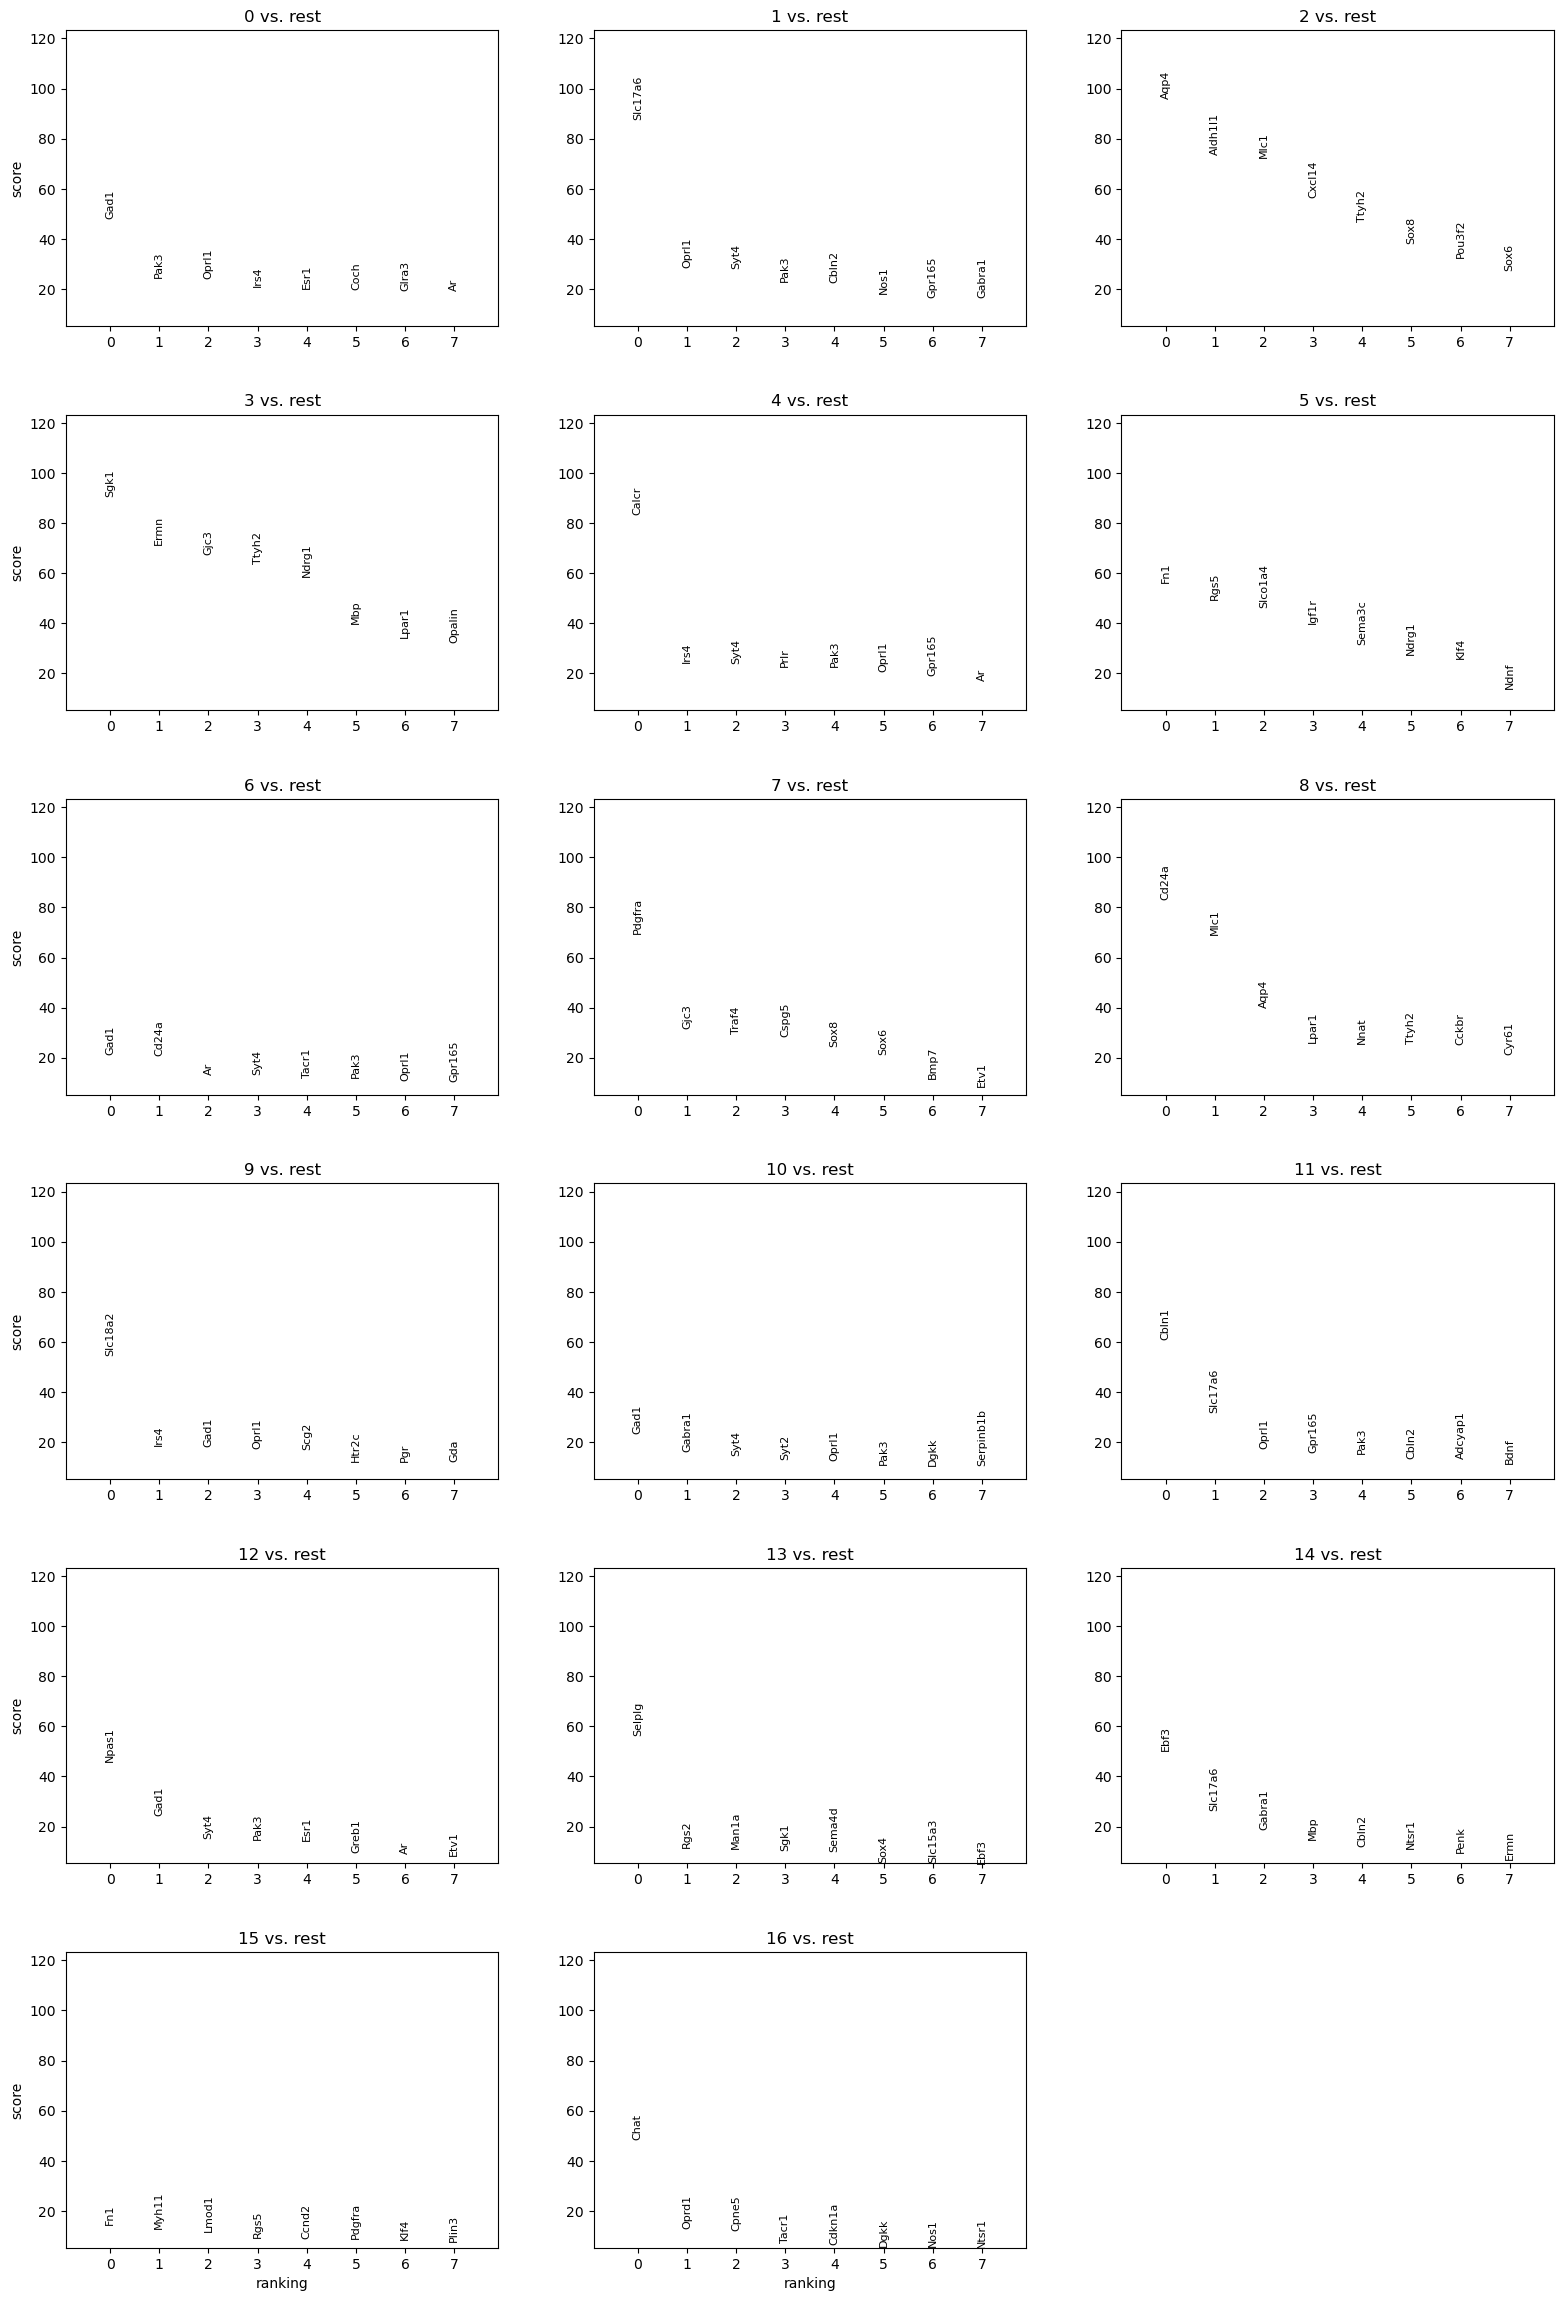

In [43]:
sc.pl.rank_genes_groups(adata_slice_min4, groupby="leiden", n_genes=8, ncols=3)